# King Saud University
College of Computer and Information Science  
Software Engineering Department  

## SW485 – Selected Topics in Software Engineering  
*2nd Semester 1447*  
# Online Purchase Prediction System  
### Phase 1 – Supervised Learning Foundation

---

## Team Members & Responsibilities

| # | Student Name | Student ID | Responsibilities |
|---|-------------|------------|------------------|
| 1 | Shahad Awaji | 443201091 | Problem definition and dataset justification |
| 2 | Hajar Alonayq | 444200784 |  |
| 3 | Raghad Alyousef | 443201008 | Preprocessing pipeline documentation, interpretation of results, key insights & challenges |
| 4 | Roaa Wadah | 443204606 | Data preprocessing implementation (cleaning, encoding, scaling) |
| 5 | Layan Aloufi | 444200663 | Exploratory Data Analysis (EDA) |
| 6 | Yasmin | — |  |
| 7 | Wijdan | — |  |

---

**Instructor:** Dr. Hailah AlMazrua  
**Section:** 4601  
**Group#1**

**Submission Date:** March 29, 2026


---


# Online Purchase Prediction System

## Introduction & Problem Statement

### Project Overview

With the rapid growth of e-commerce platforms, understanding customer behavior has become a critical challenge for online businesses. Every day, thousands of users browse online stores, but only a small percentage actually complete a purchase. Being able to identify which visitors are likely to buy a product can significantly improve business decision-making, marketing strategies, and conversion rates.

### Problem Domain

This project falls within the domain of **e-commerce analytics**, which focuses on analyzing customer behavior and interaction patterns within online shopping platforms. By analyzing browsing sessions and user engagement data, businesses can better understand purchasing behavior and optimize their marketing and recommendation strategies.

### Problem Statement

This project aims to build a machine learning system that predicts whether a user session will result in a purchase. The prediction is based on behavioral data collected during a user's interaction with an e-commerce website, such as the number of pages visited, time spent on different sections of the site, bounce rates, and visitor type.

The problem is formulated as a **binary classification task**, where the model predicts one of two outcomes:

- **Revenue = TRUE:** The user completed a purchase  
- **Revenue = FALSE:** The user left the website without purchasing

By analyzing browsing patterns and session characteristics, the system learns to distinguish between purchasing and non-purchasing sessions. Such predictions can help businesses target high-intent customers more effectively and optimize marketing resources.


---

## Dataset Selection & Justification

To address the purchase prediction problem, we selected the **Online Shoppers Intention Dataset**, which contains real browsing session data collected from an e-commerce website over a one-year period. This dataset captures detailed behavioral information about user interactions, making it highly suitable for analyzing online purchasing behavior.

### Dataset Goal

The goal of this dataset is to support the prediction of whether an online shopping session will result in a purchase. Each record represents a user browsing session and includes behavioral features describing how users interact with the website. These features allow machine learning models to learn patterns associated with purchase intention.

### Dataset Information

- **Dataset Title:** Online Shoppers Intention Dataset (UCI Machine Learning Repository)

- **Source (Kaggle URL):**  
https://www.kaggle.com/datasets/henrysue/online-shoppers-intention

- **Dataset Type:** Structured tabular dataset (session-level records)

- **Size:** 12,330 user sessions

- **Features:** 18 attributes describing browsing behavior and session characteristics, including:
  - number of pages visited and time spent on different page categories
  - bounce rate and exit rate
  - visitor type and month
  - other session-level attributes

- **Target Variable:** **Revenue**  
  Binary label indicating whether the session resulted in a purchase (**TRUE**) or not (**FALSE**).

### Why this dataset?
This dataset is suitable for the project for several reasons:

- **Relevance:** It directly matches the project objective of predicting purchase completion using online browsing behavior.
- **Completeness:** It contains a sufficient number of observations and features to support analysis, preprocessing, visualization, and model training.
- **Quality:** The dataset is well-structured, comes from a reliable academic source, and is appropriate for supervised machine learning.
- **Project Fit:** It satisfies the project requirements because it is a tabular dataset, has more than 10 features, includes thousands of records, and provides a clear binary classification target.

### License Information
- Kaggle License: **Other (specified in description)** (as stated on the Kaggle dataset page).
- Original source: UCI Machine Learning Repository  
  https://archive.ics.uci.edu/ml/datasets/Online+Shoppers+Purchasing+Intention+Dataset
  
---


## Initial Data Inspection

Before performing deeper analysis, we begin by inspecting the dataset structure.
This step helps us understand the dataset size, the types of features available,
and whether there are any missing values that may require preprocessing.

The following checks are performed:

- Viewing the first few rows of the dataset
- Examining the dataset dimensions
- Inspecting data types of each feature
- Checking for missing values

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv("/kaggle/raw_kaggle_data.csv")
df.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


The first five rows of the dataset provide an initial overview of the structure of the data.
Each row represents a single user browsing session, while each column corresponds
to a specific feature describing user behavior during the session.

In [ ]:
df.shape

(12330, 18)


The dataset contains **12,330 observations (rows)** and **18 features (columns)**.
Each observation represents a user browsing session on an e-commerce website,
and the features capture behavioral information such as page visits, duration,
and visitor characteristics.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  object 
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null  int64  
 14  TrafficType           


The `df.info()` output provides a detailed structural summary of the dataset.

It confirms that the dataset contains **12,330 entries across 18 columns**.
All columns have 12,330 non-null values, indicating that there are **no missing values**.

The dataset includes several data types:

• **Integer features (int64)**  
• **Floating-point features (float64)**  
• **Categorical features (object)**  
• **Boolean features (bool)**  

The presence of categorical and boolean variables (e.g., *Month*, *VisitorType*,
*Weekend*, *Revenue*) indicates that encoding techniques will be required
during the preprocessing stage before applying machine learning models.

In [ ]:
df.isnull().sum()

,0
Administrative,0
Administrative_Duration,0
Informational,0
Informational_Duration,0
ProductRelated,0
ProductRelated_Duration,0
BounceRates,0
ExitRates,0
PageValues,0
SpecialDay,0


### Missing Values Analysis


To ensure data quality, a missing values check was performed using `df.isnull().sum()`.

The results indicate that **all features contain zero missing values**.

This confirms that the dataset is complete and does not require any imputation
or missing-value handling before preprocessing.

In [ ]:
df.describe()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,OperatingSystems,Browser,Region,TrafficType
count,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000
mean,2.315166,80.818611,0.503569,34.472398,31.731468,1194.746220,0.022191,0.043073,5.889258,0.061427,2.124006,2.357097,3.147364,4.069586
std,3.321784,176.779107,1.270156,140.749294,44.475503,1913.669288,0.048488,0.048597,18.568437,0.198917,0.911325,1.717277,2.401591,4.025169
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000
25%,0.000000,0.000000,0.000000,0.000000,7.000000,184.137500,0.000000,0.014286,0.000000,0.000000,2.000000,2.000000,1.000000,2.000000
50%,1.000000,7.500000,0.000000,0.000000,18.000000,598.936905,0.003112,0.025156,0.000000,0.000000,2.000000,2.000000,3.000000,2.000000
75%,4.000000,93.256250,0.000000,0.000000,38.000000,1464.157214,0.016813,0.050000,0.000000,0.000000,3.000000,2.000000,4.000000,4.000000
max,27.000000,3398.750000,24.000000,2549.375000,705.000000,63973.522230,0.200000,0.200000,361.763742,1.000000,8.000000,13.000000,9.000000,20.000000


### Descriptive Statistics Analysis

The `df.describe()` output provides summary statistics for the numerical features in the dataset.

It summarizes the following statistical measures:
- Count of observations
- Mean values
- Standard deviation
- Minimum and maximum values
- Quartile distribution (25%, 50%, 75%)

From the statistical summary, we observe that:

- Duration-related features (e.g., Administrative_Duration and ProductRelated_Duration) show wide value ranges, indicating variability in user browsing time across sessions.
- BounceRates and ExitRates are small decimal values representing session-level proportions.
- Some numerical features exhibit skewed distributions due to the presence of extreme values.
- The variation in PageValues suggests differences in session engagement and purchase likelihood.

Overall, the descriptive statistics confirm that the dataset contains meaningful numerical variability and is suitable for further exploratory data analysis.


### Conclusion of Initial Inspection

The dataset has been successfully examined in terms of structure, completeness, and statistical properties.  
No missing values were detected, and the dataset contains a mixture of numerical, categorical, and boolean variables.

The data is structurally clean and ready for further **Exploratory Data Analysis (EDA)**, where we will investigate relationships between features and purchasing behavior through visualizations.

---



## Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) is a critical step in the machine learning pipeline used to understand patterns, detect anomalies, and explore relationships within the dataset.

In this project, EDA focuses on identifying the key behavioral factors that influence whether a user completes a purchase during an online shopping session.

The primary objectives of this EDA are:

1. **Data Health Assessment:** Identifying and handling missing values to ensure the model learns from high-quality and reliable data.

2. **Target Variable Analysis:** Examining the distribution of the `Revenue` column to identify potential class imbalance between buyers (True) and non-buyers (False).

3. **Feature Correlation:** Determining which session attributes—such as `PageValues`, `BounceRates`, and `ExitRates`—have the strongest statistical relationship with successful transactions.

4. **Behavioral and Seasonal Trends:** Analyzing how user purchase intent fluctuates based on temporal factors such as the `Month`.

###Dataset Overview

In [ ]:
#  Dataset Overview
print("Dimensions:", df.shape)
print("\nMissing Values:\n", df.isnull().sum())

Dimensions: (12330, 18)

Missing Values:
 Administrative             0
Administrative_Duration    0
Informational              0
Informational_Duration     0
ProductRelated             0
ProductRelated_Duration    0
BounceRates                0
ExitRates                  0
PageValues                 0
SpecialDay                 0
Month                      0
OperatingSystems           0
Browser                    0
Region                     0
TrafficType                0
VisitorType                0
Weekend                    0
Revenue                    0
dtype: int64


###Feature Analysis

In [ ]:
#  Feature Analysis
print("Unique Months:", df['Month'].unique())
print("Visitor Types:", df['VisitorType'].unique())

Unique Months: ['Feb' 'Mar' 'May' 'Oct' 'June' 'Jul' 'Aug' 'Nov' 'Sep' 'Dec']
Visitor Types: ['Returning_Visitor' 'New_Visitor' 'Other']


The dataset includes categorical features such as Month and VisitorType.
VisitorType distinguishes between returning visitors and new visitors, while Month captures seasonal behavior patterns.

###Visualization

### Visualization

To better understand the dataset and identify patterns that influence purchase behavior, several visualizations were performed.

1. **Target Variable Distribution (Revenue)**  
   Since the main goal of this project is to predict whether a user will make a purchase, it is important to first examine the distribution of the target variable **Revenue**.

   This visualization shows how many browsing sessions resulted in a purchase (True) and how many did not (False). Understanding this distribution helps identify whether the dataset is balanced or imbalanced, which may affect model performance later.  









5. **Seasonality Analysis**  
   The **Month** variable was analyzed to understand whether purchase behavior varies across different times of the year.

1. Visualize the Target Variable (Revenue)
Since the goal is to predict purchases, we must see how many sessions actually resulted in revenue.

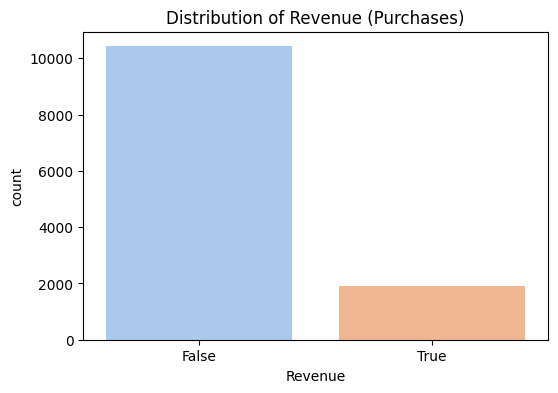

Revenue
False    84.525547
True     15.474453
Name: proportion, dtype: float64


In [41]:
import seaborn as sns
import matplotlib.pyplot as plt

# Plotting the distribution of Revenue
plt.figure(figsize=(6, 4))
sns.countplot(x='Revenue', data=df, hue='Revenue', palette='pastel', legend=False)
plt.title('Distribution of Revenue (Purchases)')
plt.show()

# Print the exact percentage of shoppers who bought something
print(df['Revenue'].value_counts(normalize=True) * 100)

The distribution of the target variable **Revenue** shows that most sessions do not result in a purchase.

This indicates that the dataset is **imbalanced**, meaning that non-purchase sessions significantly outnumber purchase sessions. Such imbalance is common in e-commerce datasets because most visitors browse without buying.

This observation is important because class imbalance can influence machine learning model performance and may require special handling during the modeling stage.


2. **Page Value vs Purchase Behavior**  
   To understand which behavioral features influence purchasing decisions, we analyze the relationship between **PageValues** and the target variable **Revenue**.
  
   PageValues represent the average value of a webpage based on how frequently it contributes to transactions. Higher values indicate pages that are more likely to lead to purchases.
   
   A **boxplot** is used to compare the distribution of PageValues between sessions that resulted in a purchase (Revenue = True) and sessions that did not (Revenue = False).

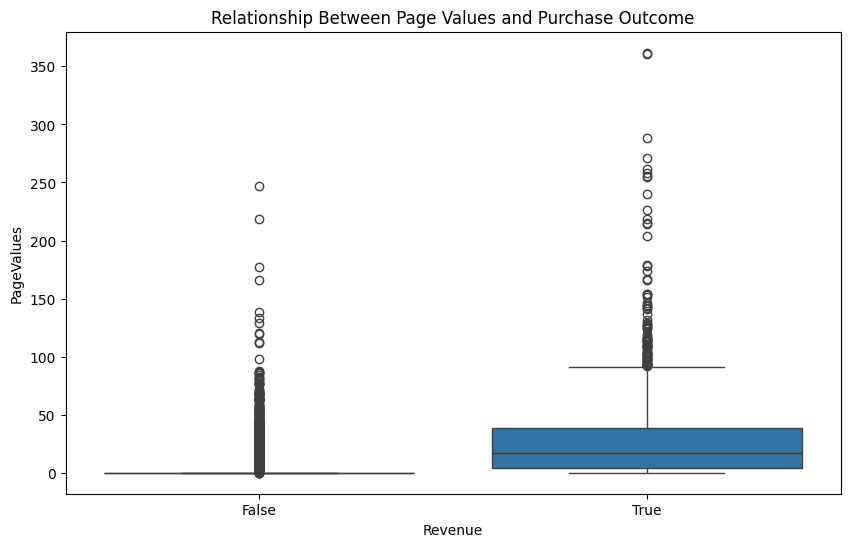

In [42]:
# Boxplot for PageValues vs Revenue
plt.figure(figsize=(10, 6))
sns.boxplot(x='Revenue', y='PageValues', data=df)
plt.title('Relationship Between Page Values and Purchase Outcome')
plt.show()


The boxplot shows a clear difference in PageValues between purchasing and non-purchasing sessions.

Sessions that resulted in purchases (**Revenue = True**) generally have significantly higher PageValues compared to sessions where no purchase occurred (**Revenue = False**).

This suggests that PageValues is a strong indicator of purchase intent. Users who visit pages with higher PageValues are more likely to complete a transaction.

Therefore, PageValues may be an important predictive feature for the machine learning model.

3. **Feature Correlation Analysis**  
   To better understand relationships between numerical features in the dataset, a **correlation heatmap** is used.
   
   Correlation measures how strongly two variables are related. The correlation values range from **-1 to 1**:
   - **1** indicates a strong positive relationship  
   - **0** indicates no relationship  
   - **-1** indicates a strong negative relationship
   
   By visualizing correlations between features, we can identify which variables are strongly related and detect potential redundancy between features. This helps improve feature selection and model performance in later stages.

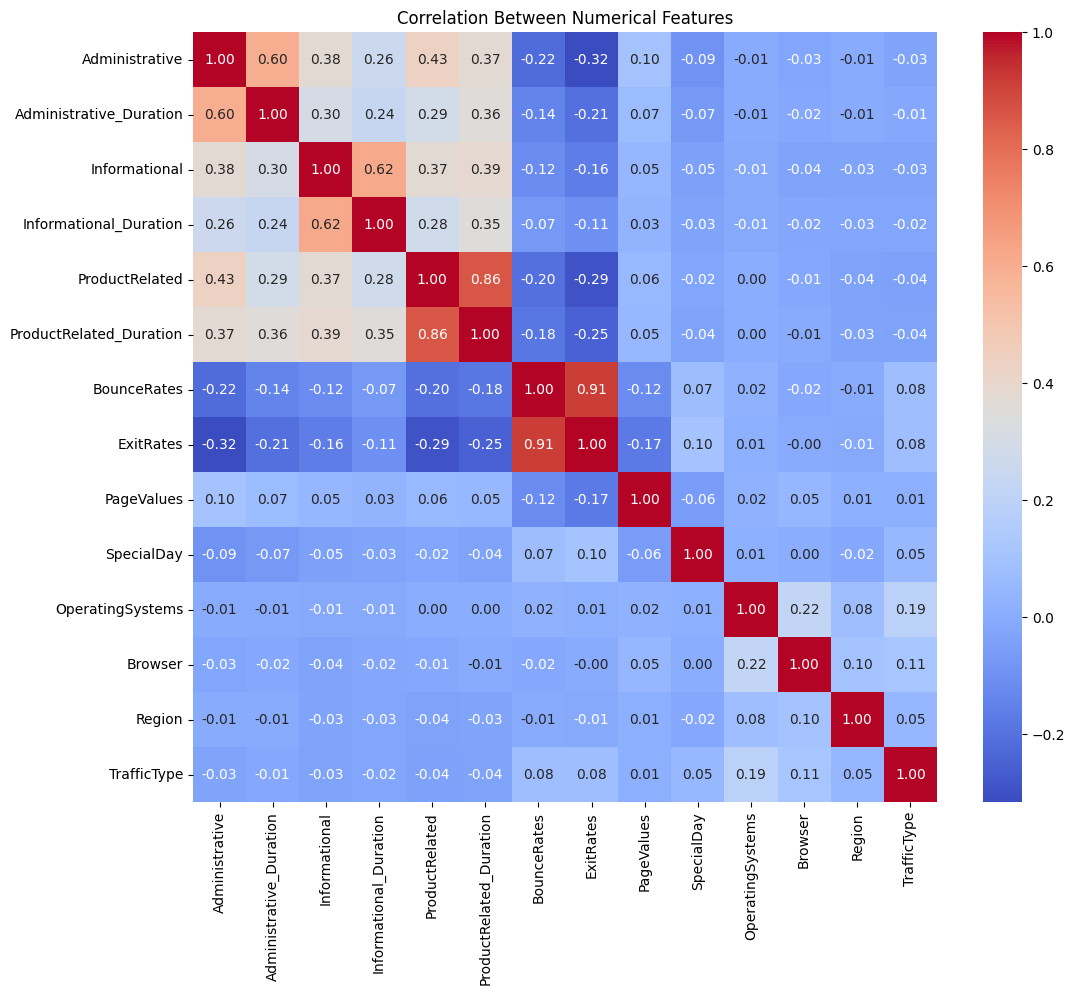

In [43]:
plt.figure(figsize=(12, 10))
# Calculate correlation only for numerical columns
sns.heatmap(df.select_dtypes(include=['float64', 'int64']).corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Between Numerical Features')
plt.show()


The correlation heatmap reveals several important relationships between numerical features.

A very strong positive correlation is observed between **BounceRates** and **ExitRates** (~0.91), indicating that both metrics capture very similar user behavior. This suggests that users who frequently leave pages quickly also tend to exit the website shortly afterward.

Another notable relationship exists between **ProductRelated** and **ProductRelated_Duration**, which show a strong positive correlation (~0.86). This indicates that users who visit more product-related pages also tend to spend more time on those pages.

Most other features show weak or moderate correlations, suggesting that they contribute unique information to the dataset.

Overall, the heatmap helps identify key relationships between features and highlights behavioral indicators that may influence purchasing behavior.

4. **Seasonality Analysis (Monthly Purchase Behavior)**  
   Online shopping activity often varies depending on the time of the year due to holidays, promotions, and seasonal demand.  
  
   To explore potential seasonal patterns, we analyze how purchase behavior changes across different months. The following visualization compares the number of sessions that resulted in purchases (**Revenue = True**) and those that did not (**Revenue = False**) for each month.
   
   This helps determine whether certain months show higher purchasing activity.


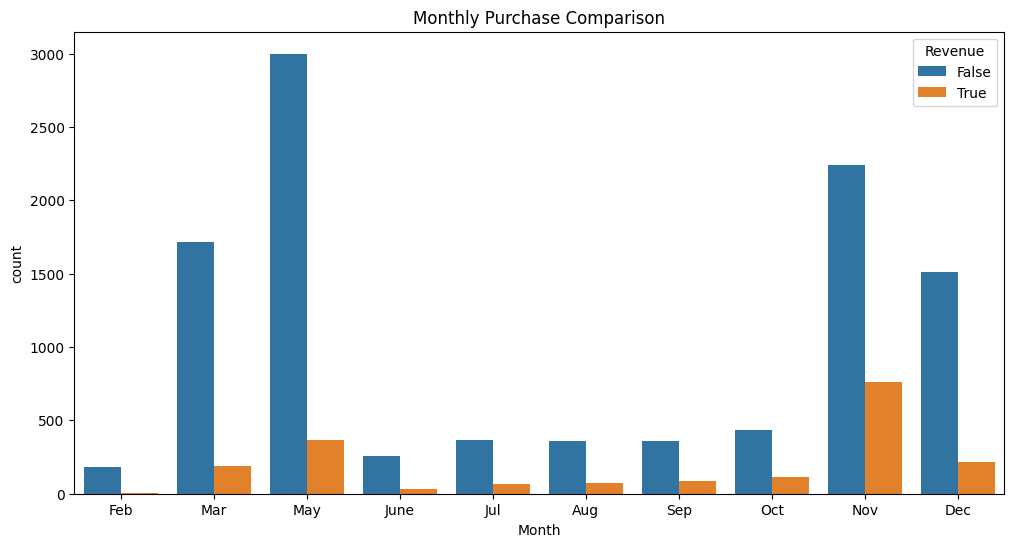

In [ ]:
plt.figure(figsize=(12, 6))
sns.countplot(x='Month', hue='Revenue', data=df,
              order=['Feb', 'Mar', 'May', 'June', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.title('Monthly Purchase Comparison')
plt.show()

The visualization shows that browsing sessions occur throughout the year, but the number of sessions resulting in purchases varies across months.

Certain months, such as **November and May**, appear to have a higher number of purchase events compared to other months. This may be related to seasonal shopping trends, promotional events, or increased consumer activity during specific periods.

Overall, the results suggest that **seasonality may influence online purchasing behavior**, making the Month feature potentially useful for predicting purchase intent in the machine learning model.


5. **Bounce Rate Distribution**  
   Bounce rate represents the percentage of visitors who leave the website after viewing only one page without interacting further.
   
   Analyzing the distribution of **BounceRates** helps us understand how users behave during browsing sessions and whether most users quickly leave the website or continue interacting with multiple pages.
   
   The following histogram visualizes the distribution of bounce rates across all sessions.


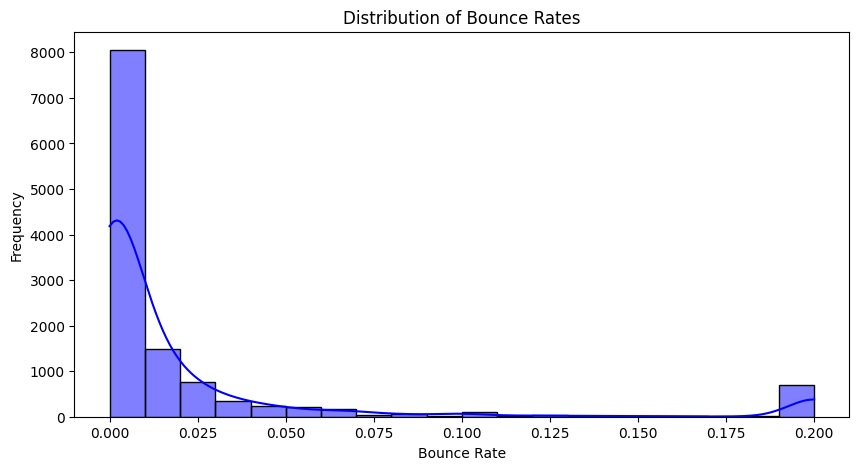

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
sns.histplot(df['BounceRates'], bins=20, kde=True, color='blue')
plt.title('Distribution of Bounce Rates')
plt.xlabel('Bounce Rate')
plt.ylabel('Frequency')
plt.show()


The histogram shows that most bounce rate values are very close to **0**, indicating that many users do not leave the website immediately and instead interact with multiple pages during their browsing sessions.

However, there are also sessions with higher bounce rates, suggesting that some users leave the website quickly without further interaction.

This variation in bounce rate behavior may provide useful information for predicting purchasing outcomes, as users who engage more with the website are generally more likely to complete a purchase.



6. **Comparison of Page Values by Revenue**  
   To further examine how user behavior relates to purchasing outcomes, we compare the **PageValues** feature between sessions that resulted in purchases and sessions that did not.
   
   PageValues represent the estimated value of a webpage based on how frequently it contributes to transactions. Higher PageValues indicate pages that are more strongly associated with purchases.
   
   The following boxplot compares PageValues between **buyers (Revenue = True)** and **non-buyers (Revenue = False)**.

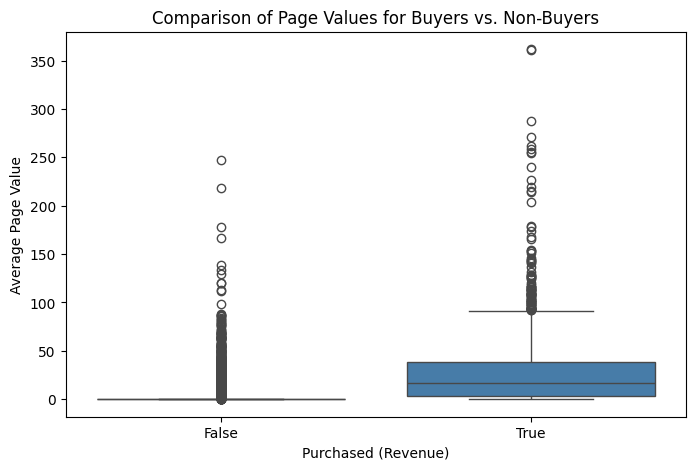

In [44]:
import seaborn as sns
import matplotlib.pyplot as plt

# Comparison 1: PageValues vs. Revenue
plt.figure(figsize=(8, 5))
sns.boxplot(x='Revenue', y='PageValues', data=df, hue='Revenue', palette='Set1', legend=False)
plt.title('Comparison of Page Values for Buyers vs. Non-Buyers')
plt.xlabel('Purchased (Revenue)')
plt.ylabel('Average Page Value')
plt.show()


The visualization shows that sessions resulting in purchases (**Revenue = True**) generally have much higher PageValues compared to sessions without purchases (**Revenue = False**).

Most non-purchasing sessions have PageValues close to zero, while purchasing sessions show a wider range of higher values.

This suggests that PageValues is a strong indicator of purchase intent, as users interacting with higher-value pages are more likely to complete a transaction. Therefore, PageValues may serve as an important predictive feature for the machine learning model.

7. **Comparison of Bounce Rates by Revenue**  
   To further understand how user engagement relates to purchasing behavior, we analyze the relationship between **BounceRates** and the target variable **Revenue**.
   
   Bounce rate measures the percentage of visitors who leave the website after viewing only a single page without further interaction. A high bounce rate usually indicates low user engagement.
   
   The following violin plot compares the distribution of bounce rates between sessions that resulted in purchases (**Revenue = True**) and sessions that did not (**Revenue = False**).

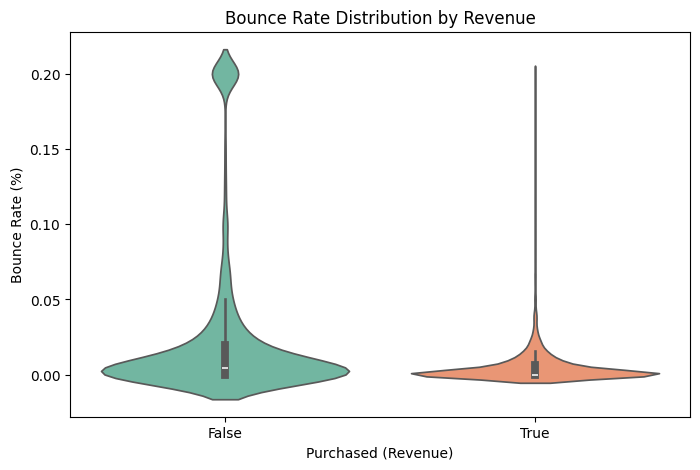

In [45]:
# Comparison 2: BounceRates vs. Revenue
plt.figure(figsize=(8, 5))
sns.violinplot(x='Revenue', y='BounceRates', data=df, hue='Revenue', palette='Set2', legend=False)
plt.title('Bounce Rate Distribution by Revenue')
plt.xlabel('Purchased (Revenue)')
plt.ylabel('Bounce Rate (%)')
plt.show()


The visualization shows that sessions resulting in purchases (**Revenue = True**) generally have lower bounce rates compared to sessions without purchases (**Revenue = False**).

Most purchasing sessions are concentrated near very low bounce rate values, indicating that users who stay longer and interact with multiple pages are more likely to complete a transaction.

In contrast, sessions with higher bounce rates are more common among non-purchasing sessions. This suggests that bounce rate can be an important indicator of user engagement and may contribute to predicting purchase behavior.



### Key Insights
1. **Class Imbalance:**  
   The dataset is imbalanced, with most sessions resulting in **Revenue = False**, meaning most visitors browse without making purchases.

2. **Strong Behavioral Indicator:**  
   The feature **PageValues** shows a clear difference between purchasing and non-purchasing sessions, indicating strong predictive potential.

3. **User Engagement:**  
   Higher **BounceRates** are associated with sessions that do not lead to purchases, suggesting that users who leave pages quickly are less likely to buy.

4. **Seasonality:**  
   Purchase behavior varies across different months, indicating seasonal trends in online shopping activity.

   ---



## Data Preprocessing & Feature Engineering

Before applying machine learning models, the dataset must be transformed into a format suitable for numerical computation. Most machine learning algorithms require numerical inputs and consistent feature scales to operate effectively.

During this stage, several preprocessing techniques were applied to clean and transform the dataset. These steps included handling missing values, encoding categorical variables into numerical representations, and standardizing numerical features.

These transformations ensure that the dataset is compatible with machine learning algorithms and that no feature dominates the learning process due to differences in scale.

### Preprocessing Pipeline

The following preprocessing steps were applied to prepare the dataset for machine learning modeling:

**1. Handling Missing Values**

During the initial inspection stage, the dataset was examined for missing values. No missing values were detected across the features. Therefore, no imputation or value removal was required.

**2. Label Encoding**

Boolean variables such as `Revenue` and `Weekend` were converted from True/False values into numerical form (1/0) using Label Encoding.

Justification: Machine learning algorithms require numerical inputs to compute mathematical operations such as probability estimation and distance calculations.

**3. One-Hot Encoding**

Categorical variables including `Month` and `VisitorType` were transformed into binary dummy variables using one-hot encoding.

Justification: One-hot encoding prevents the model from incorrectly assuming an ordinal relationship between categories (for example, assuming that one month is "greater" than another).

**4. Feature Scaling**

Continuous numerical features were standardized using `StandardScaler`.

Justification: Many machine learning algorithms are sensitive to the scale of input features. Standardization ensures that all numerical features contribute equally during model training.



In [39]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder, StandardScaler

df_processed = df.copy()

df_processed.dropna(inplace=True)

le = LabelEncoder()
df_processed['Revenue'] = le.fit_transform(df_processed['Revenue'])
df_processed['Weekend'] = le.fit_transform(df_processed['Weekend'])

categorical_cols = ['Month', 'VisitorType']
df_processed = pd.get_dummies(df_processed, columns=categorical_cols, drop_first=True)

scaler = StandardScaler()
numerical_cols = ['Administrative', 'Administrative_Duration', 'Informational',
                  'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration',
                  'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay']

df_processed[numerical_cols] = scaler.fit_transform(df_processed[numerical_cols])

df_processed.to_csv('preprocessed_data.csv', index=False)

print("Preprocessing is Complete!")
print(f"New dataset shape: {df_processed.shape}")
display(df_processed.head())

Preprocessing is Complete!
New dataset shape: (12330, 27)


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,...,Month_Feb,Month_Jul,Month_June,Month_Mar,Month_May,Month_Nov,Month_Oct,Month_Sep,VisitorType_Other,VisitorType_Returning_Visitor
0,-0.696993,-0.457191,-0.396478,-0.244931,-0.691003,-0.624348,3.667189,3.229316,-0.317178,-0.308821,...,True,False,False,False,False,False,False,False,False,True
1,-0.696993,-0.457191,-0.396478,-0.244931,-0.668518,-0.590903,-0.457683,1.171473,-0.317178,-0.308821,...,True,False,False,False,False,False,False,False,False,True
2,-0.696993,-0.457191,-0.396478,-0.244931,-0.691003,-0.624348,3.667189,3.229316,-0.317178,-0.308821,...,True,False,False,False,False,False,False,False,False,True
3,-0.696993,-0.457191,-0.396478,-0.244931,-0.668518,-0.622954,0.573535,1.994610,-0.317178,-0.308821,...,True,False,False,False,False,False,False,False,False,True
4,-0.696993,-0.457191,-0.396478,-0.244931,-0.488636,-0.296430,-0.045196,0.142551,-0.317178,-0.308821,...,True,False,False,False,False,False,False,False,False,True



### Preprocessed Dataset Ready for Modeling

After applying the preprocessing pipeline, the dataset was successfully transformed into a machine-learning-ready format.

All categorical variables were converted into numerical representations through encoding techniques, and numerical features were standardized to ensure consistent feature scales. The target variable **Revenue** was converted into a binary numerical label suitable for classification tasks.

The final processed dataset was exported as **preprocessed_data.csv**, which will be used in the next stage of the project for training and evaluating supervised learning models.

In [40]:
#verification code
df_processed.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 27 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Administrative                 12330 non-null  float64
 1   Administrative_Duration        12330 non-null  float64
 2   Informational                  12330 non-null  float64
 3   Informational_Duration         12330 non-null  float64
 4   ProductRelated                 12330 non-null  float64
 5   ProductRelated_Duration        12330 non-null  float64
 6   BounceRates                    12330 non-null  float64
 7   ExitRates                      12330 non-null  float64
 8   PageValues                     12330 non-null  float64
 9   SpecialDay                     12330 non-null  float64
 10  OperatingSystems               12330 non-null  int64  
 11  Browser                        12330 non-null  int64  
 12  Region                         12330 non-null 



**Key Insights**

- The dataset required minimal cleaning since no missing values were detected during the inspection phase.

- Encoding techniques were necessary to transform categorical variables into numerical representations compatible with machine learning algorithms.

- Feature scaling ensured that numerical variables operate on comparable scales, preventing features with larger magnitudes from dominating the model learning process.


**Challenges**

- The dataset contains a mixture of categorical, numerical, and boolean features, which required multiple preprocessing techniques.

- The target variable exhibits **class imbalance**, as most sessions result in no purchase. This imbalance may affect model performance and must be considered during model training and evaluation.

### Next Step

With the dataset now preprocessed and ready for modeling, the next phase of the project will focus on applying and evaluating machine learning classification models to predict whether a website session will result in a purchase.